# 🏠 Bengaluru House Price - Exploratory Data Analysis (EDA)

This notebook explores the Bengaluru House Price dataset to understand its structure,
find missing values, study correlations, and visualize distributions before building
our Linear Regression model.

**Sections:**
1. Dataset Overview
2. Missing Values
3. Data Cleaning (using preprocessing.py)
4. Price Distribution
5. BHK Distribution
6. Distribution Plots (Total Sqft, Bath)
7. Correlation Analysis
8. Feature Importance Discussion


In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Make plots look a bit nicer
sns.set_style("whitegrid")
%matplotlib inline


## 1. Dataset Overview

In [2]:
# Load the raw dataset
df = pd.read_csv("../Bengaluru_House_Data.csv")

print("Shape of dataset:", df.shape)
df.head()


Shape of dataset: (13320, 9)


,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


In [3]:
# Basic info about columns and data types
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  str    
 1   availability  13320 non-null  str    
 2   location      13319 non-null  str    
 3   size          13304 non-null  str    
 4   society       7818 non-null   str    
 5   total_sqft    13320 non-null  str    
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), str(6)
memory usage: 1.6 MB


In [4]:
# Summary statistics for numeric columns
df.describe()


,bath,balcony,price
count,13247.000000,12711.000000,13320.000000
mean,2.692610,1.584376,112.565627
std,1.341458,0.817263,148.971674
min,1.000000,0.000000,8.000000
25%,2.000000,1.000000,50.000000
50%,2.000000,2.000000,72.000000
75%,3.000000,2.000000,120.000000
max,40.000000,3.000000,3600.000000


## 2. Missing Values

In [5]:
# Check missing values in each column
df.isnull().sum()


area_type          0
availability       0
location           1
size              16
society         5502
total_sqft         0
bath              73
balcony          609
price              0
dtype: int64

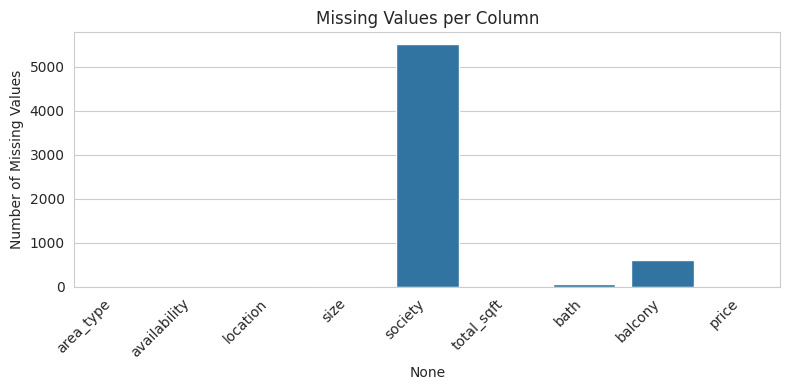

In [6]:
# Visualize missing values
plt.figure(figsize=(8, 4))
sns.barplot(x=df.isnull().sum().index, y=df.isnull().sum().values)
plt.xticks(rotation=45, ha='right')
plt.ylabel("Number of Missing Values")
plt.title("Missing Values per Column")
plt.tight_layout()
plt.show()


## 3. Data Cleaning

We reuse the same cleaning steps from `preprocessing.py` so that our EDA
matches exactly what the model will be trained on.


In [7]:
# Import our preprocessing pipeline
import sys
sys.path.append("..")
from preprocessing import preprocess_pipeline

clean_df = preprocess_pipeline("../Bengaluru_House_Data.csv")
print("Cleaned dataset shape:", clean_df.shape)
clean_df.head()


Cleaned dataset shape: (9689, 7)


,area_type,location,total_sqft,bath,balcony,price,bhk
0,Super built-up Area,Electronic City Phase II,1056.0,2.0,1.0,39.07,2
1,Plot Area,Chikka Tirupathi,2600.0,5.0,3.0,120.00,4
2,Built-up Area,Uttarahalli,1440.0,2.0,3.0,62.00,3
3,Super built-up Area,Lingadheeranahalli,1521.0,3.0,1.0,95.00,3
4,Super built-up Area,Kothanur,1200.0,2.0,1.0,51.00,2


## 4. Price Distribution

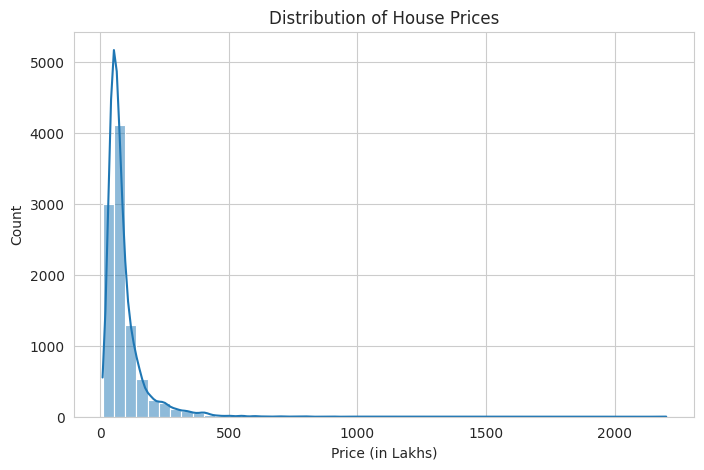

In [8]:
plt.figure(figsize=(8, 5))
sns.histplot(clean_df['price'], bins=50, kde=True)
plt.xlabel("Price (in Lakhs)")
plt.title("Distribution of House Prices")
plt.show()


## 5. BHK Distribution

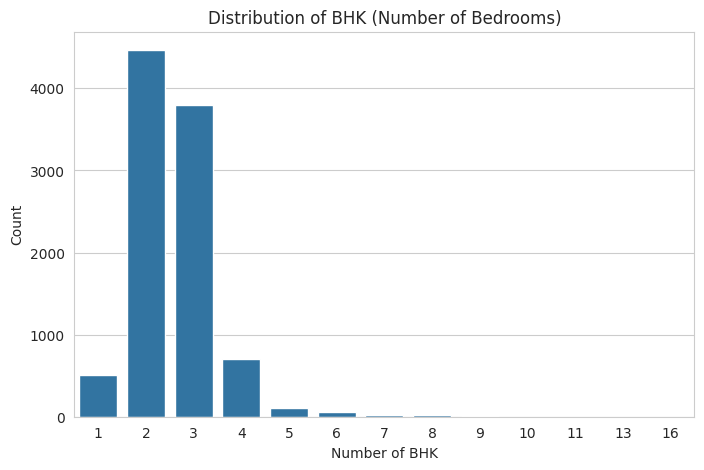

In [9]:
plt.figure(figsize=(8, 5))
sns.countplot(x='bhk', data=clean_df, order=sorted(clean_df['bhk'].unique()))
plt.xlabel("Number of BHK")
plt.ylabel("Count")
plt.title("Distribution of BHK (Number of Bedrooms)")
plt.show()


## 6. Distribution Plots (Total Sqft & Bathrooms)

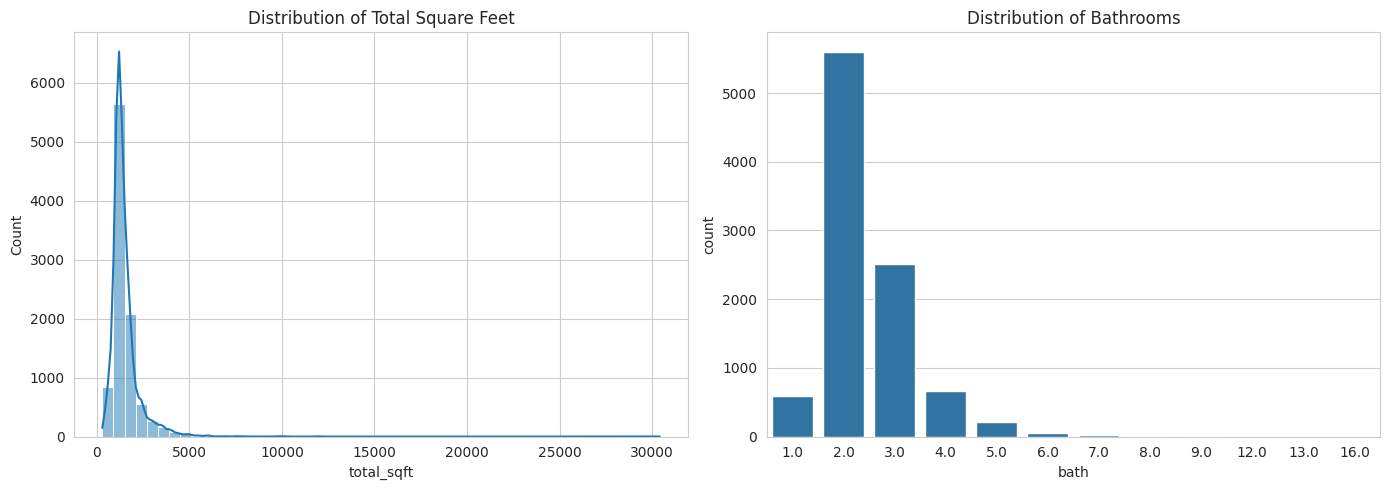

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(clean_df['total_sqft'], bins=50, kde=True, ax=axes[0])
axes[0].set_title("Distribution of Total Square Feet")

sns.countplot(x='bath', data=clean_df, ax=axes[1])
axes[1].set_title("Distribution of Bathrooms")

plt.tight_layout()
plt.show()


## 7. Correlation Analysis

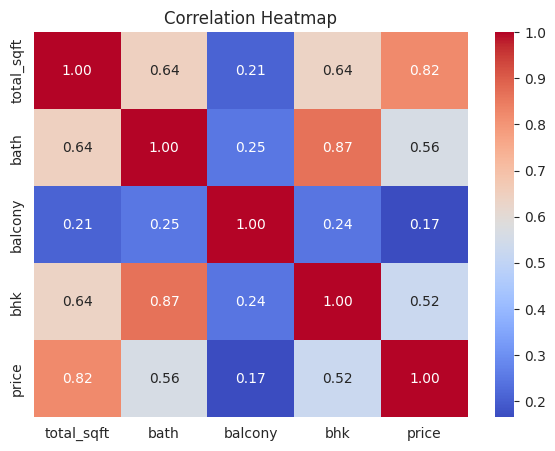

In [11]:
# Correlation between numeric features
numeric_cols = ['total_sqft', 'bath', 'balcony', 'bhk', 'price']
corr = clean_df[numeric_cols].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()


## 8. Feature Importance Discussion

Based on the correlation heatmap and plots above:

- **total_sqft** shows the strongest positive correlation with `price`.
  Larger homes tend to cost more, which matches real-world intuition.
- **bhk** (number of bedrooms) is also positively correlated with price,
  but it is closely related to `total_sqft` (bigger homes usually have more rooms).
- **bath** and **balcony** have a smaller, but still positive, influence on price.
- **location** and **area_type** are categorical, so they don't show up in the
  numeric correlation heatmap, but they matter a lot in real estate pricing.
  We handle them using One-Hot Encoding before training the model.

Overall, `total_sqft` and `location` are expected to be the most important
features for predicting house prices in this dataset.
